In [1]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier

# 1. LOAD DATA
df = pd.read_csv('Final_Cleaned_Panel_Dataset.csv')

# 2. TARGET VARIABLE
df['Flood_Occurred'] = ((df['Total_Flood_Events'] > 0) | (df['Indo_Event_Count'] > 0)).astype(int)

# 3. FEATURES
features = [
    'Annual_Tree_Loss_ha', 
    'Annual_Percent_Tree_Loss',
    'Annual_Rainfall', 
    'Monsoon_Rainfall', 
    'Max_Daily_Rainfall',
    'Lagged_Annual_Tree_Loss_ha', 
    'Lagged_Annual_Percent_Tree_Loss',
    'Lagged_Annual_Rainfall', 
    'Lagged_Monsoon_Rainfall'
]

existing_features = [f for f in features if f in df.columns]

# 4. TIME-BASED SPLIT (CRITICAL)
train_df = df[df['Year'] <= 2018]
test_df  = df[df['Year'] > 2018]

X_train = train_df[existing_features]
y_train = train_df['Flood_Occurred']

X_test = test_df[existing_features]
y_test = test_df['Flood_Occurred']

print(f"Train Size: {len(X_train)}, Test Size: {len(X_test)}")
print(f"Train Floods: {y_train.sum()}, Test Floods: {y_test.sum()}\n")

# 5. SIMPLE IMPUTATION (SHAP-FRIENDLY)

# Compute medians ONLY from training data (no leakage)
train_medians = X_train.median()

# Fill missing values
X_train = X_train.fillna(train_medians)
X_test  = X_test.fillna(train_medians)

# 6. RANDOM FOREST (TUNING)
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

# 7. XGBOOST (TUNING)
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [4, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8]
}

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False),
    xgb_params,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_

# 8. EVALUATION FUNCTION
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    return {
        "Model": name,
        "Accuracy (%)": round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 3),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 3),
        "F1-Score": round(f1_score(y_test, y_pred, zero_division=0), 3),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4)
    }

# 9. FINAL COMPARISON
results = []

results.append(evaluate_model("Random Forest (Tuned)", rf_best, X_test, y_test))
results.append(evaluate_model("XGBoost (Tuned)", xgb_best, X_test, y_test))

results_df = pd.DataFrame(results)

print("="*70)
print("🏆 FINAL MODEL PERFORMANCE (LEAKAGE-FREE + TIME-AWARE)")
print("="*70)
print(results_df.to_string(index=False))

# 10. BEST MODEL SELECTION
best_model = xgb_best if results_df.loc[1, 'ROC-AUC'] > results_df.loc[0, 'ROC-AUC'] else rf_best

print("\n✅ Best Model Selected:", type(best_model).__name__)

Train Size: 576, Test Size: 64
Train Floods: 341, Test Floods: 42



C:\Users\singh\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [20:34:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🏆 FINAL MODEL PERFORMANCE (LEAKAGE-FREE + TIME-AWARE)
                Model  Accuracy (%)  Precision  Recall  F1-Score  ROC-AUC
Random Forest (Tuned)         73.44      0.857   0.714     0.779   0.8593
      XGBoost (Tuned)         73.44      0.821   0.762     0.790   0.8193

✅ Best Model Selected: RandomForestClassifier


In [2]:
import shap

explainer = shap.TreeExplainer(rf_best)
shap_values = explainer(X_test)

# Extract class 1 contributions
shap_values_class1 = shap_values.values[:, :, 1]

C:\Users\singh\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print(shap_values_class1.shape)

(64, 9)


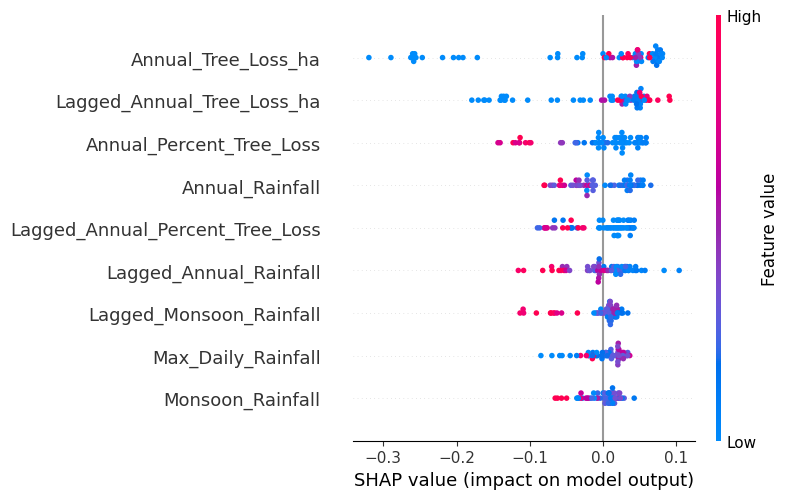

In [4]:
shap.summary_plot(shap_values_class1, X_test)

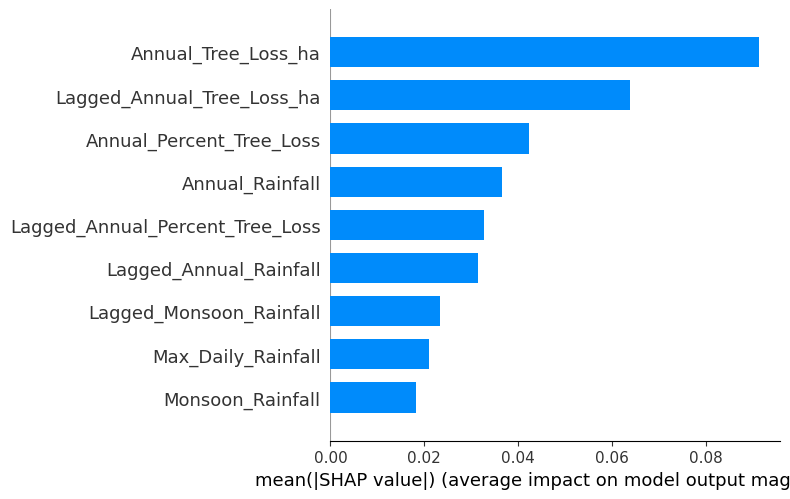

In [5]:
shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

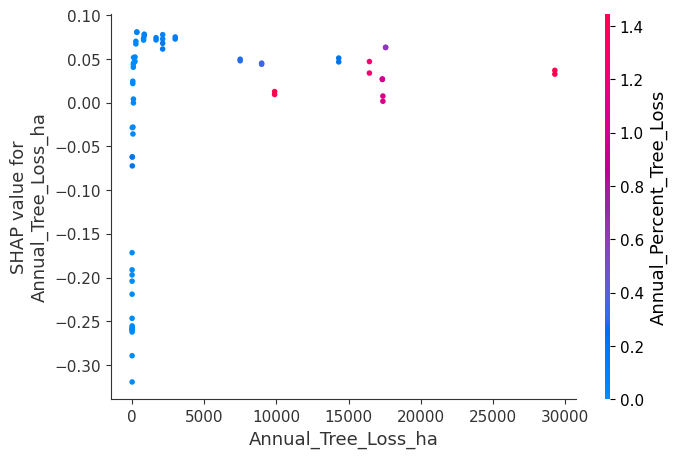

In [8]:
shap.dependence_plot("Annual_Tree_Loss_ha", shap_values_class1, X_test)

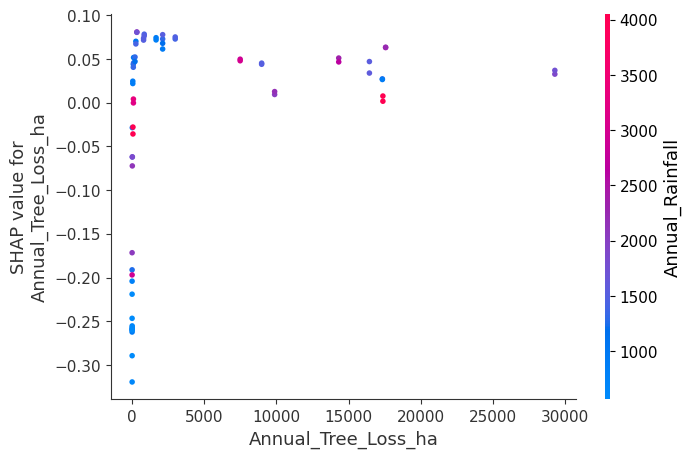

In [9]:
shap.dependence_plot(
    "Annual_Tree_Loss_ha",
    shap_values_class1,
    X_test,
    interaction_index="Annual_Rainfall"
)

In [10]:
ts = df.groupby("Year")["Flood_Occurred"].sum()

In [11]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=5)

C:\Users\singh\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\singh\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\singh\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\singh\AppData\Local\Programs\Python\Python310\lib

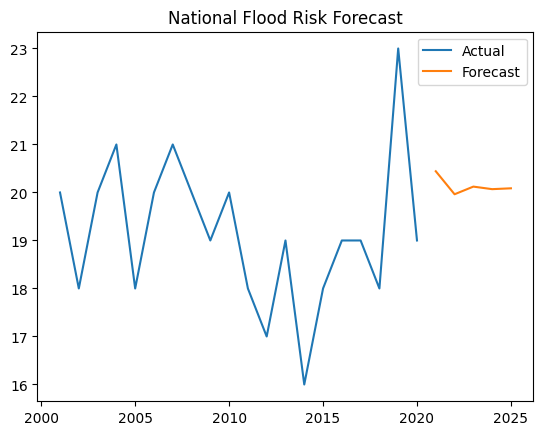

In [12]:
import matplotlib.pyplot as plt

plt.plot(ts, label="Actual")
plt.plot(range(ts.index[-1]+1, ts.index[-1]+6), forecast, label="Forecast")
plt.legend()
plt.title("National Flood Risk Forecast")
plt.show()

In [13]:
import numpy as np

feature = X_test["Annual_Tree_Loss_ha"].values
impact = shap_values_class1[:, existing_features.index("Annual_Tree_Loss_ha")]

# sort
sorted_idx = np.argsort(feature)
feature_sorted = feature[sorted_idx]
impact_sorted = impact[sorted_idx]

In [14]:
threshold = feature_sorted[np.where(impact_sorted > 0)[0][0]]
print("Tree loss tipping point:", threshold)

Tree loss tipping point: 47.2


In [15]:
state_risk = df.groupby("State")["Flood_Occurred"].mean().sort_values(ascending=False)
print(state_risk.head())

State
Assam             1.0
Karnataka         1.0
Kerala            1.0
Madhya Pradesh    1.0
Maharashtra       1.0
Name: Flood_Occurred, dtype: float64


In [22]:
import geopandas as gpd

india_map = gpd.read_file("gadm41_IND_1.shp")

merged = india_map.merge(state_risk, on="State")

merged.plot(column="Flood_Occurred", cmap="Reds", legend=True)

KeyError: 'State'

In [18]:
from sklearn.cluster import KMeans

cluster_data = df.groupby("State")[[
    "Annual_Rainfall",
    "Annual_Tree_Loss_ha",
    "Flood_Occurred"
]].mean()

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_data["Cluster"] = kmeans.fit_predict(cluster_data)

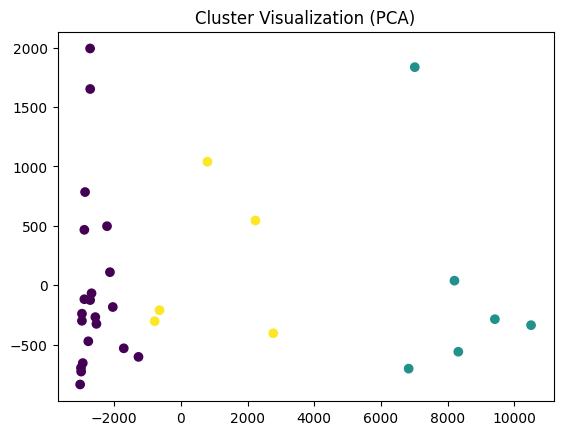

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(cluster_data.drop("Cluster", axis=1))

plt.scatter(reduced[:,0], reduced[:,1], c=cluster_data["Cluster"])
plt.title("Cluster Visualization (PCA)")
plt.show()

C:\Users\singh\AppData\Local\Temp\ipykernel_12316\2562532739.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cluster_data["Annual_Rainfall"][i],
C:\Users\singh\AppData\Local\Temp\ipykernel_12316\2562532739.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cluster_data["Annual_Tree_Loss_ha"][i],


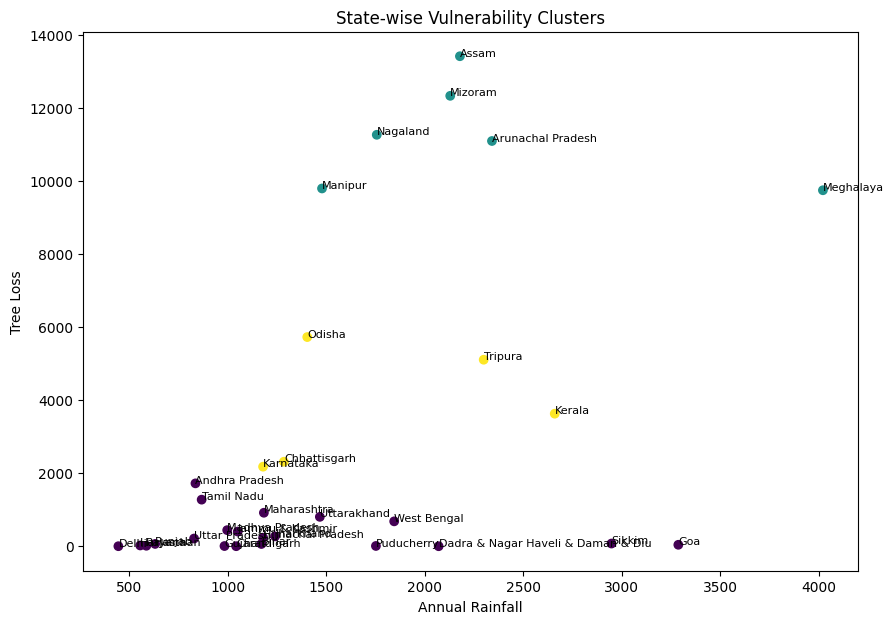

In [20]:
plt.figure(figsize=(10,7))

plt.scatter(
    cluster_data["Annual_Rainfall"],
    cluster_data["Annual_Tree_Loss_ha"],
    c=cluster_data["Cluster"]
)

for i, state in enumerate(cluster_data.index):
    plt.text(
        cluster_data["Annual_Rainfall"][i],
        cluster_data["Annual_Tree_Loss_ha"][i],
        state,
        fontsize=8
    )

plt.xlabel("Annual Rainfall")
plt.ylabel("Tree Loss")
plt.title("State-wise Vulnerability Clusters")

plt.show()